**CS377 Final Project**

Predicting the 2026 FIFA World Cup Winner

Author: Kieara Blackwood

Professor: Jonathan Lee

Date: May 10, 2026

**Introduction**

With the 2026 FIFA World Cup set to begin on June 11th, this project aims to determine which national team is most likely to secure the championship. As a major soccer fan and someone who will be tuning in to watch the upcoming tournament, I am excited to see if the data supports a potential title win for my favorite team, England. Thus, by analyzing historical tournament data and previous team performances, the project will specifically investigate the statistical probability of England winning the title.


The primary research question is: Which nation is most likely to win the 2026 World Cup?

Secondary Questions:


*   What is the likelihood of the English national team winning?
*   Who are the predicted runner-up, third-place, and fourth-place finishers?
*   How should the model handle countries that no longer exist?


**Dataset:** world_cups.csv - source from Kaggle (Zhuang, 2023)

Contains World Cup tournaments from 1930 - 2022 with columns: Year, Host Country, Winner, Runners-Up, Third, Fourth, Goals Scored, Qualified Teams, and Matches Played.


**Imports**


Standard data manipulation and numerical libraries:


*   pandas as pd
*   numpy as np


Visualization of data libraries:


*   seaborn as sns
*   matplotlib.pyplot as plt
*   matplotlib.ticker as mticker


Scikit-learn: model building, evaluation, and preprocessing:


*   train_test_split
*   LogisticRegression
*   RandomForestClassifier
*   Confusion_matrix, accuracy_score, classification_report
*   ConfusionMatrixDisplay
*   StandardScaler



In [1]:
#Load Libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

**Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving world_cups.csv to world_cups.csv


**Data Description**

For this project I gathered my data from the online website, Kaggle. This dataset called Soccer World Cup 2022 Prediction, was created by Shi Long Zhuang. For the purpose of this project, I will only be working with the world_cups.csv dataset file. The dataset covers all 22 FIFA World Cup tournaments from 1930 to 2022, with one row per tournament.


In [3]:
#data loading
df = pd.read_csv("world_cups.csv")

#Preview the first 5 rows in order to understand the data
df.head()

,Year,Host Country,Winner,Runners-Up,Third,Fourth,Goals Scored,Qualified Teams,Matches Played
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26


**Inspect the Dataset**

**Data Types**
The dataset consists of 22 rows of data that are broken down into categorical and numeric categories.

**Categorical:** Host Country, Winner, Runners-Up, Third, Fourth

**Numeric:** Year, Goals Scored, Qualified Teams, and Matches Played

In [4]:
# Displays column data types and non-null counts
# Helps to identify which columns needs to be cleaned or converted
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             22 non-null     int64 
 1   Host Country     22 non-null     object
 2   Winner           22 non-null     object
 3   Runners-Up       22 non-null     object
 4   Third            22 non-null     object
 5   Fourth           22 non-null     object
 6   Goals Scored     22 non-null     int64 
 7   Qualified Teams  22 non-null     int64 
 8   Matches Played   22 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 1.7+ KB


In [5]:
# Displays descriptive statistics for numerical columns
# Gives a summary of the range, mean, and spread
display(df.describe())

,Year,Goals Scored,Qualified Teams,Matches Played
count,22.000000,22.000000,22.000000,22.000000
mean,1978.909091,123.636364,22.227273,43.818182
std,27.738419,34.841882,7.602830,17.632860
min,1930.000000,70.000000,13.000000,17.000000
25%,1959.000000,90.500000,16.000000,32.000000
50%,1980.000000,129.000000,20.000000,45.000000
75%,2001.000000,146.750000,32.000000,64.000000
max,2022.000000,172.000000,32.000000,64.000000


In [6]:
# Categorical: number of unique categories
print("\nCategorical Statistics:")
print(df[['Winner', 'Runners-Up', 'Third', 'Fourth']].nunique())


Categorical Statistics:
Winner         9
Runners-Up    11
Third         15
Fourth        17
dtype: int64


**Data Cleaning**

Before the modeling process begins, I need to clean and standardize the dataset.

Key issues that need to be addressed:


* **Outliers:**
Countries that do not exist anymore. Examples: Germany FR, Yugoslavia, Czechoslovakia, Soviet Union. I will remap them to their modern equivalents so that the data is concise and accurate.

*   **Missing Rows**:
There is only one row that is missing data. For the 2022 Qatar World Cup there are missing values for Winner, Runners-Up, Third, Fourth, and Goals Scored. This is likely because the dataset was compiled before the tournament concluded. I will handle this missing data by inputting the remaining data myself.

* **Missing values:** Verify that there are no missing values after cleaning


In [7]:
# Created a map to rename countries that no longer exist
# These countries will be maped to there modern equivalents
rename_map = {
    'Germany FR': 'Germany',
    'Czechoslovakia': 'Czech Republic',
    'Soviet Union': 'Russia',
    'Yugoslavia': 'Serbia',
    'Korea Republic': 'South Korea',
}

# Added the mapping to every column
position_cols = ['Winner', 'Runners-Up', 'Third', 'Fourth', 'Host Country']
for col in position_cols:
    df[col] = df[col].replace(rename_map)

In [8]:
#Verify no missing data
print(df.isna().sum())

Year               0
Host Country       0
Winner             0
Runners-Up         0
Third              0
Fourth             0
Goals Scored       0
Qualified Teams    0
Matches Played     0
dtype: int64


In [9]:
# Preview of the cleaned dataset
df.head(22)

,Year,Host Country,Winner,Runners-Up,Third,Fourth,Goals Scored,Qualified Teams,Matches Played
0,1930,Uruguay,Uruguay,Argentina,USA,Serbia,70,13,18
1,1934,Italy,Italy,Czech Republic,Germany,Austria,70,16,17
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22
4,1954,Switzerland,Germany,Hungary,Austria,Uruguay,140,16,26
5,1958,Sweden,Brazil,Sweden,France,Germany,126,16,35
6,1962,Chile,Brazil,Czech Republic,Chile,Serbia,89,16,32
7,1966,England,England,Germany,Portugal,Russia,89,16,32
8,1970,Mexico,Brazil,Italy,Germany,Uruguay,95,16,32
9,1974,Germany,Germany,Netherlands,Poland,Brazil,97,16,38


**Exploratory Data Analysis (EDA)**

I explored the dataset in order to understand the distributions, trends, and patterns. This step helps with identifying which features are the most predictive and informative for feature engineering.

/tmp/ipykernel_843/2524889566.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')


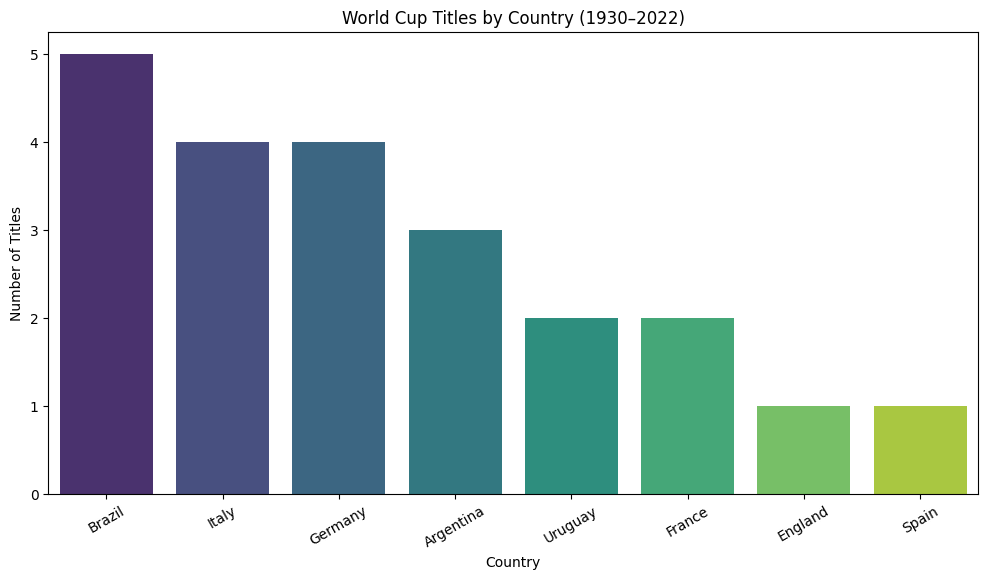

In [10]:
# Bar Chart: World Cup Titles by Country
# Shows which countries have the most World Cup Titles
winner_counts = df['Winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')
plt.title('World Cup Titles by Country (1930–2022)')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=30)
plt.show()

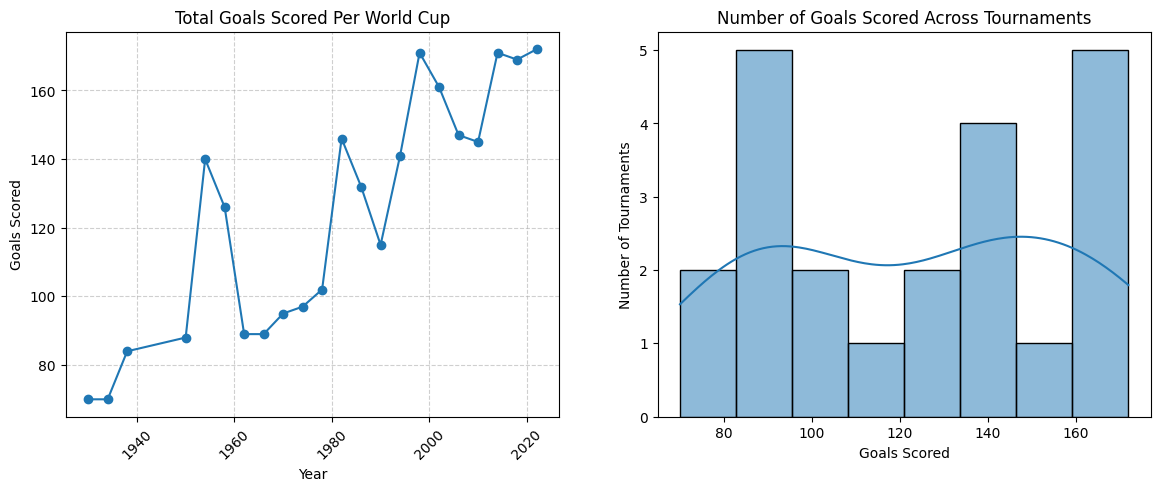

In [11]:
# Line Chart and Histogram: Goals Scored Over Time
# Shows tournament expansion

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line Chart: goals over the years
axes[0].plot(df['Year'], df['Goals Scored'], marker='o')
axes[0].set_title('Total Goals Scored Per World Cup')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Goals Scored')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].tick_params(axis='x', rotation=45)

# Histogram: distribution of goals scored
sns.histplot(df['Goals Scored'], bins=8, kde=True)
axes[1].set_title('Number of Goals Scored Across Tournaments')
axes[1].set_xlabel('Goals Scored')
axes[1].set_ylabel('Number of Tournaments')

plt.show()

# Adding more teams and more matches leads to more goals

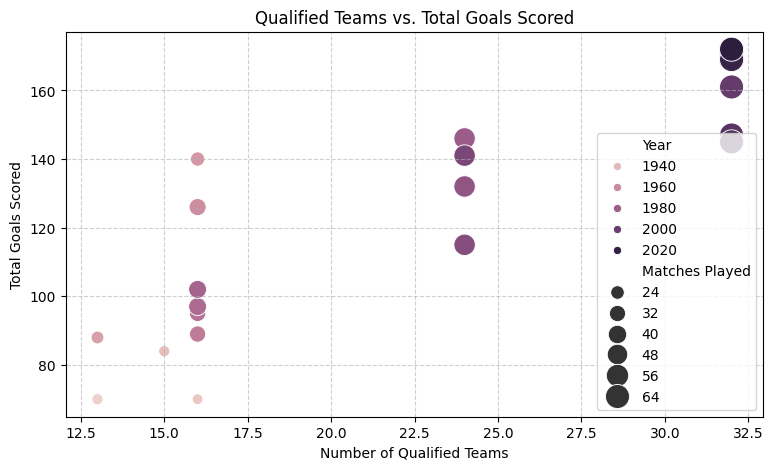

Pearson correlation between Qualified Teams and Goals Scored: 0.890


In [12]:
# Scatter Plot: Qualified Teams vs Goals Scored
# Tests whether more participating teams correlates to more goals
plt.figure(figsize=(9, 5))

sns.scatterplot(data=df, x='Qualified Teams', y='Goals Scored', hue='Year', size='Matches Played', sizes=(60, 300))
plt.title('Qualified Teams vs. Total Goals Scored')
plt.xlabel('Number of Qualified Teams')
plt.ylabel('Total Goals Scored')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Correlation coefficient
# Shows the correlation between Qualified Teams and Goals Scored
corr = df['Qualified Teams'].corr(df['Goals Scored'])
print(f"Pearson correlation between Qualified Teams and Goals Scored: {corr:.3f}")

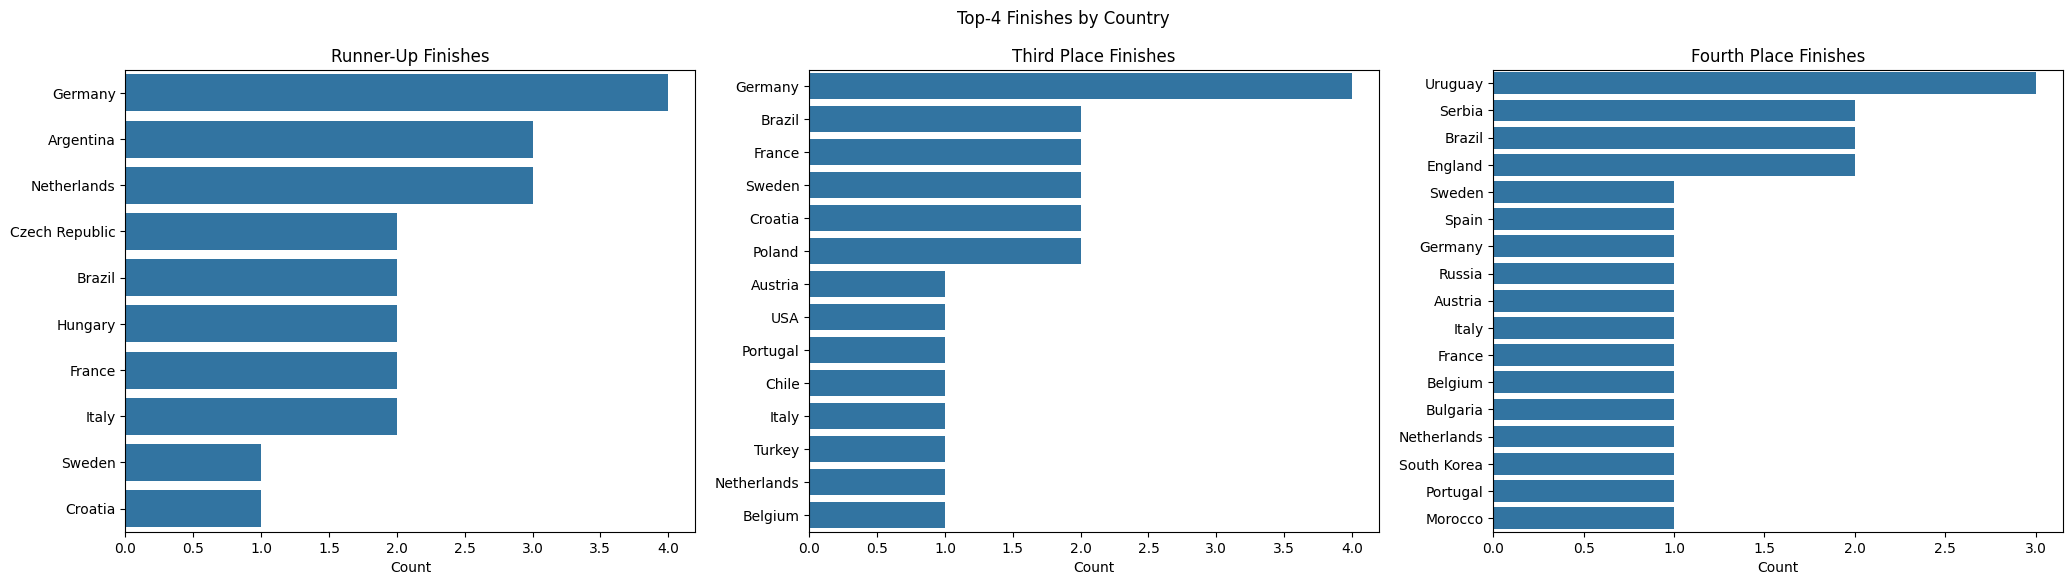

In [13]:
# Bar Plot: Runner-Up and Top-4 Count
# Shows which countries have made a top 4 finish
runner_up_counts  = df['Runners-Up'].value_counts()
third_counts      = df['Third'].value_counts()
fourth_counts     = df['Fourth'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(25, 6))

for ax, counts, title in zip(
        axes,
        [runner_up_counts, third_counts, fourth_counts],
        ['Runner-Up Finishes', 'Third Place Finishes', 'Fourth Place Finishes']):

    sns.barplot(x=counts.values, y=counts.index, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.suptitle('Top-4 Finishes by Country')
plt.show()

# Countries who have repeatedly reached the final are stronger title contenders compared to countries that have not

In [14]:
# Host Country Performance
# Question that is being answered: Does hosting a tournament give a country an advantage?
df['Host Won'] = (df['Host Country'] == df['Winner']).astype(int)
host_wins = df['Host Won'].sum()
total_tournaments = len(df)

print(f"Times the host country won: {host_wins}/{total_tournaments}")
print(f"Host win rate: {host_wins / total_tournaments:.1%}")

# Show which host countries won
host_winners = df[df['Host Won'] == 1][['Year', 'Host Country', 'Winner']]
display(host_winners)

Times the host country won: 6/22
Host win rate: 27.3%


,Year,Host Country,Winner
0,1930,Uruguay,Uruguay
1,1934,Italy,Italy
7,1966,England,England
9,1974,Germany,Germany
10,1978,Argentina,Argentina
15,1998,France,France


**Defining Features Variables**

**DV/IV Assumptions**

**Dependent Variable (DV):** winner column. I plan on handling the data by reshaping it into a binary format where 1 represents a win and 0 represents a loss.

**Independent Variables (IVs):**

* **Host country:** it will be used to calculate the home team advantage via a boolean variable.

* **Previous Performance:** it will calculate the frequency of a country's finishing as the winner, runner-up, third, or fourth place.

* **Year:** it will be used to account for recency bias. This variable will prioritize current standings over outdated results.

* **Qualified Teams:** it will be used to calculate competition density across different tournament eras as the number of participants has increased.


**Exceptional Entries**
For the Qualified Team column, it shows a significant increase in tournament size. It has grown from 13 teams in 1930 to 32 teams by 2022, which affects competition density.

**Data Transformation and Rescaling**

**Binary:** The target variable (Winner) will be transformed into a binary format (1/0)

**Boolean:** The Host Country variable will be converted into a boolean variable in order to calculate home-field advantage.

**Weighting:** Recency Bias will act as a weight system to favor modern data over historical results.


The dataset has only 22 rows (one per tournament). To build a meaningful classifier, I need to reshape the data so that each row represents a (tournament, country) pair. I also need to create a target variable (Winner) that defines whether a specific country won that tournament.

**Independent Variables (IVs) Created:**

**wins_so_far:** Calcualtes the number of wins

**runner_up_so_far:**	Calculates the number of runner-up finishes

**third_so_far:**	Calculates the number of third-place finishes

**fourth_so_far:** Calculates the number of fourth-place finishes

**is_host:** Calculates home-field advantage

**recency_score:** Weighted sum of recent finishes. It prioritizes most recent performances over 1930s results

**qualified_teams:** Calcualtes competition density. The more teams = harder to win

**top4_so_far:** Combines the top-4 finishes


In [15]:
# All countries that have placed in the top 4
all_countries = sorted(set(
    df['Winner'].tolist() +
    df['Runners-Up'].tolist() +
    df['Third'].tolist() +
    df['Fourth'].tolist()
))
print(f"Total countries in top-4: {len(all_countries)}")
print(all_countries)

Total countries in top-4: 25
['Argentina', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Chile', 'Croatia', 'Czech Republic', 'England', 'France', 'Germany', 'Hungary', 'Italy', 'Morocco', 'Netherlands', 'Poland', 'Portugal', 'Russia', 'Serbia', 'South Korea', 'Spain', 'Sweden', 'Turkey', 'USA', 'Uruguay']


In [16]:
# Build one row per (tournament,country) pair
# The question being asked by each row: "Did this country win this specific tournament?"
# Tracks the cumulative stats UP TO (but not including) the current tournament

records = []

for idx, row in df.iterrows():
    year             = row['Year']
    host             = row['Host Country']
    winner           = row['Winner']
    qualified_teams  = row['Qualified Teams']

    # All tournaments BEFORE the current tournament year
    past = df[df['Year'] < year]

    for country in all_countries:
        # Cumulative count
        wins_so_far      = (past['Winner']     == country).sum()
        runner_up_so_far = (past['Runners-Up'] == country).sum()
        third_so_far     = (past['Third']       == country).sum()
        fourth_so_far    = (past['Fourth']      == country).sum()
        top4_so_far      = wins_so_far + runner_up_so_far + third_so_far + fourth_so_far

        # Host-country advantage
        is_host = 1 if country == host else 0

        # Recency score: weights recent results more heavily
        # Formula: for each past tournament, award points by time
        # Win = 4 pts, Runner-up = 3 pts, Third = 2 pts, Fourth = 1 pt
        # Each point is multiplied by (past_year / current_year) so recent results score higher than older ones.

        recency_score = 0
        for _, p in past.iterrows():
            weight = p['Year'] / year
            if p['Winner'] == country: recency_score += 4 * weight
            if p['Runners-Up'] == country: recency_score += 3 * weight
            if p['Third'] == country: recency_score += 2 * weight
            if p['Fourth'] == country: recency_score += 1 * weight

        # Target variable: did this country win this tournament?
        won = 1 if winner == country else 0

        records.append({
            'year'           : year,
            'country'        : country,
            'won'            : won,
            'wins_so_far'    : wins_so_far,
            'runner_up_so_far': runner_up_so_far,
            'third_so_far'   : third_so_far,
            'fourth_so_far'  : fourth_so_far,
            'top4_so_far'    : top4_so_far,
            'is_host'        : is_host,
            'recency_score'  : recency_score,
            'qualified_teams': qualified_teams,
        })

# Convert the list to a dataset
model_df = pd.DataFrame(records)

print(f"Dataset: {model_df.shape}")
print(f"Total 'won=1' rows: {model_df['won'].sum()} (one per tournament)")
model_df.head(10)

Dataset: (550, 11)
Total 'won=1' rows: 22 (one per tournament)


,year,country,won,wins_so_far,runner_up_so_far,third_so_far,fourth_so_far,top4_so_far,is_host,recency_score,qualified_teams
0,1930,Argentina,0,0,0,0,0,0,0,0.0,13
1,1930,Austria,0,0,0,0,0,0,0,0.0,13
2,1930,Belgium,0,0,0,0,0,0,0,0.0,13
3,1930,Brazil,0,0,0,0,0,0,0,0.0,13
4,1930,Bulgaria,0,0,0,0,0,0,0,0.0,13
5,1930,Chile,0,0,0,0,0,0,0,0.0,13
6,1930,Croatia,0,0,0,0,0,0,0,0.0,13
7,1930,Czech Republic,0,0,0,0,0,0,0,0.0,13
8,1930,England,0,0,0,0,0,0,0,0.0,13
9,1930,France,0,0,0,0,0,0,0,0.0,13


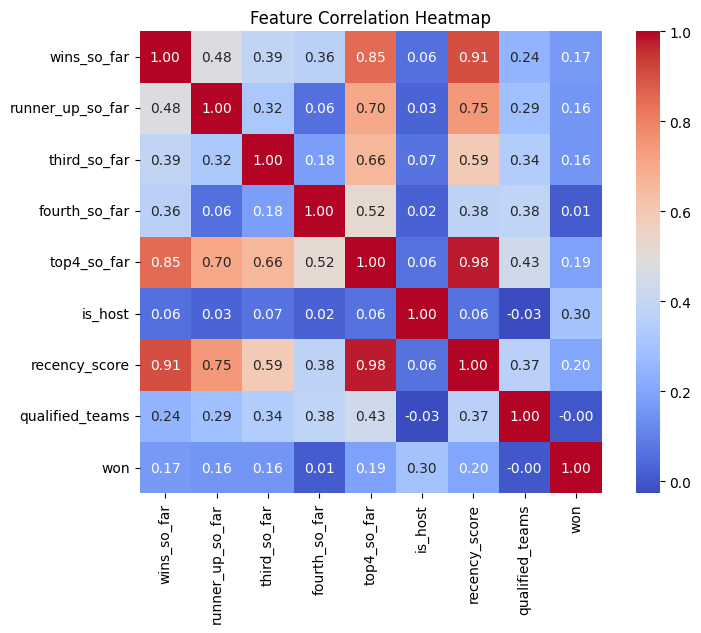

In [17]:
# Correlation heatmap
# Purpose: to measure the strength and direction of the linear relationship between the features
# Helps to see which variables have the highest correlation with a team winning
# Detects multicollinearity
feature_cols = ['wins_so_far', 'runner_up_so_far', 'third_so_far',
                'fourth_so_far', 'top4_so_far', 'is_host',
                'recency_score', 'qualified_teams']

plt.figure(figsize=(9, 6))
corr_matrix = model_df[feature_cols + ['won']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

**Model Training and Evaluation**

In [18]:
# Prepare features (X) and target (y)
# top4_so_far will be droped to reduce multicollinearity
X = model_df[['wins_so_far', 'runner_up_so_far', 'third_so_far',
               'fourth_so_far', 'is_host', 'recency_score', 'qualified_teams']]
y = model_df['won']

# Train/Test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 440
Testing samples: 110


**Logistic Regression**

Predicts the probability of a specific country winning the tournament. It will look for patterns within the independent variables in order to output the probablity (dependent variable) for the target nation.

In [19]:
# Feature Scaling
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions for the test set
lr_preds = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_preds)

print("LOGISTIC REGRESSION RESULTS")
print(f"Accuracy: {lr_acc:.4f} ({lr_acc:.1%})")
print()
print(classification_report(y_test, lr_preds, target_names=['Did Not Win', 'Won']))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.9455 (94.5%)

              precision    recall  f1-score   support

 Did Not Win       0.96      0.98      0.97       106
         Won       0.00      0.00      0.00         4

    accuracy                           0.95       110
   macro avg       0.48      0.49      0.49       110
weighted avg       0.93      0.95      0.94       110



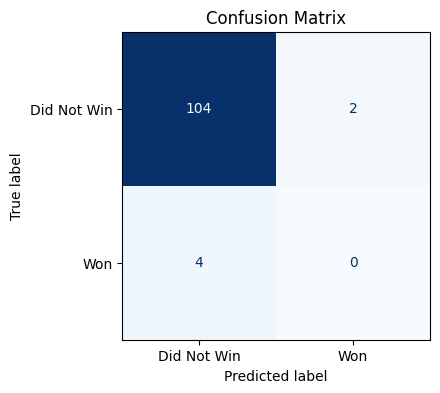

In [21]:
# Confusion Matrix
# Evaluate the performance of the classification model by showing exactly where it is making correct and incorrect predictions.
# True Positive (TP): correctly predicted a winner
# True Negative (TN): correctly predicted a non-winner
# False Positive (FP): predicted win, but team didn't win
# False Negative (FN): predicted no win, but team actually won

fig, ax = plt.subplots(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Did Not Win', 'Won'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix')

plt.show()

**Random Forest**

Determines the probability of a specific country winning the tournament. It acts as a second opinion to see if it reaches the same conclusion of the chances of winning the tournament.

In [22]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predictions for the test set
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)


print("RANDOM FOREST RESULTS")
print(f"Accuracy: {rf_acc:.4f} ({rf_acc:.1%})")
print()
print(classification_report(y_test, rf_preds, target_names=['Did Not Win', 'Won']))

RANDOM FOREST RESULTS
Accuracy: 0.8727 (87.3%)

              precision    recall  f1-score   support

 Did Not Win       0.98      0.89      0.93       106
         Won       0.14      0.50      0.22         4

    accuracy                           0.87       110
   macro avg       0.56      0.69      0.58       110
weighted avg       0.95      0.87      0.90       110



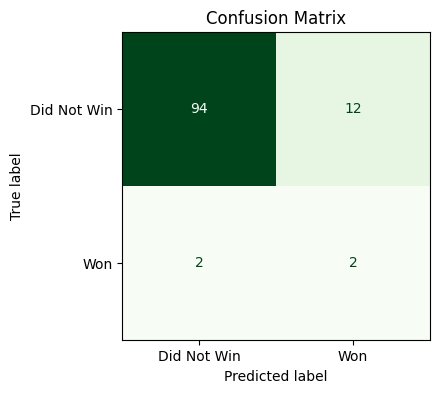

In [23]:
# Confusion Matrix
# Evaluate the performance of the model by showing exactly where it is making correct and incorrect predictions.
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, rf_preds)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Did Not Win', 'Won'])

disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix')
plt.show()

**2026 World Cup Predictions**

Now that both models are trained, I need to predict probability of the winner for the 2026 FIFA World Cup. I built a 2026 feature vector for each country using the data from the previous 22 World Cups (1930 - 2022).

In [24]:
# Building 2026 feature row for each country
# The 2026 World Cup will have 48 qualified teams and be hosted by USA, Canada, and Mexico
# For simplicity, USA will be considered the main host
# USA = 1 since the majority of matches will be played there.

YEAR_2026 = 2026
QUALIFIED_2026 = 48
HOST_2026 = 'USA'

pred_records = []

for country in all_countries:
    # Use past tournaments data
    wins_so_far      = (df['Winner']     == country).sum()
    runner_up_so_far = (df['Runners-Up'] == country).sum()
    third_so_far     = (df['Third']       == country).sum()
    fourth_so_far    = (df['Fourth']      == country).sum()

    is_host = 1 if country == HOST_2026 else 0

    # Recency score up to 2022
    recency_score = 0
    for _, row in df.iterrows():
        weight = row['Year'] / YEAR_2026
        if row['Winner']     == country: recency_score += 4 * weight
        if row['Runners-Up'] == country: recency_score += 3 * weight
        if row['Third']       == country: recency_score += 2 * weight
        if row['Fourth']      == country: recency_score += 1 * weight

    pred_records.append({
        'country'          : country,
        'wins_so_far'      : wins_so_far,
        'runner_up_so_far' : runner_up_so_far,
        'third_so_far'     : third_so_far,
        'fourth_so_far'    : fourth_so_far,
        'is_host'          : is_host,
        'recency_score'    : recency_score,
        'qualified_teams'  : QUALIFIED_2026,
    })

pred_df = pd.DataFrame(pred_records)
display(pred_df)

,country,wins_so_far,runner_up_so_far,third_so_far,fourth_so_far,is_host,recency_score,qualified_teams
0,Argentina,3,3,0,0,0,20.605133,48
1,Austria,0,0,1,1,0,2.883514,48
2,Belgium,0,0,1,1,0,2.972359,48
3,Brazil,5,2,2,2,0,31.198421,48
4,Bulgaria,0,0,0,1,0,0.984205,48
5,Chile,0,0,1,0,0,1.936821,48
6,Croatia,0,1,2,0,0,6.956565,48
7,Czech Republic,0,2,0,0,0,5.769003,48
8,England,1,0,0,2,0,5.859822,48
9,France,2,2,2,1,0,18.765054,48


In [25]:
# Run both models on the 2026 feature vectors
X_pred = pred_df[['wins_so_far', 'runner_up_so_far', 'third_so_far','fourth_so_far', 'is_host', 'recency_score', 'qualified_teams']]

# Logistic Regression: scale features first, then get probability of winning
X_pred_scaled = scaler.transform(X_pred)
lr_probs = lr_model.predict_proba(X_pred_scaled)[:, 1]

# Random Forest
rf_probs = rf_model.predict_proba(X_pred)[:, 1]

# Average of both model probabilities
models_probs = (lr_probs + rf_probs) / 2

# Add the probabilities to the prediction dataset
pred_df['LR_prob'] = lr_probs
pred_df['RF_prob'] = rf_probs
pred_df['Models_prob'] = models_probs

# Sort by model probability (descending)
pred_df_sorted = pred_df.sort_values('Models_prob', ascending=False).reset_index(drop=True)

print("2026 FIFA World Cup Win Probability Predictions")
display(pred_df_sorted[['country', 'wins_so_far', 'recency_score','LR_prob', 'RF_prob', 'Models_prob']].head(15))

2026 FIFA World Cup Win Probability Predictions


,country,wins_so_far,recency_score,LR_prob,RF_prob,Models_prob
0,Germany,4,36.196446,0.455504,0.648658,0.552081
1,France,2,18.765054,0.028599,0.639779,0.334189
2,Brazil,5,31.198421,0.056425,0.548649,0.302537
3,Argentina,3,20.605133,0.042193,0.561036,0.301614
4,Italy,4,24.328727,0.043909,0.549954,0.296932
5,USA,0,1.905232,0.136370,0.406599,0.271485
6,Croatia,0,6.956565,0.021430,0.255682,0.138556
7,Sweden,0,7.749260,0.006467,0.241892,0.124179
8,Netherlands,0,11.802567,0.004370,0.179168,0.091769
9,Spain,1,4.930898,0.001934,0.154291,0.078113


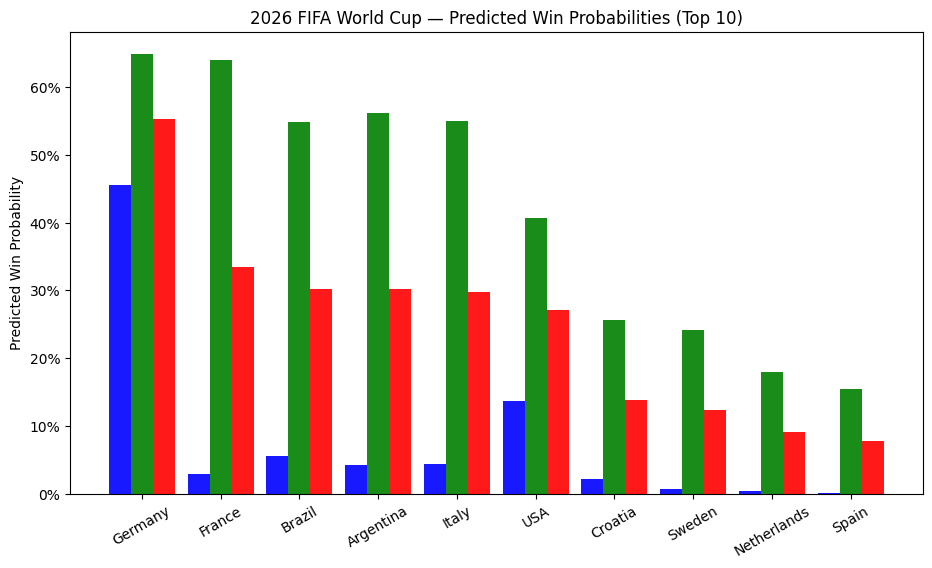

In [26]:
# Top 10 Predicted Winners
top10 = pred_df_sorted.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(top10))
width = 0.28

ax.bar(x - width, top10['LR_prob'], width, label='Logistic Regression',color='blue', alpha=0.9)
ax.bar(x,top10['RF_prob'], width, label='Random Forest',color='green', alpha=0.9)
ax.bar(x + width, top10['Models_prob'], width, label='Models (Average)',color='red', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(top10['country'], rotation=30)
ax.set_ylabel('Predicted Win Probability')
ax.set_title('2026 FIFA World Cup — Predicted Win Probabilities (Top 10)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.show()

In [27]:
# Probablity of England Winning
england_row = pred_df_sorted[pred_df_sorted['country'] == 'England']
england_rank = england_row.index[0] + 1  # 1-indexed rank


print("ENGLAND 2026 WORLD CUP PREDICTION")
print(f"Wins: {england_row['wins_so_far'].values[0]}")
print(f"Recency Score: {england_row['recency_score'].values[0]:.2f}")
print(f"Logistic Regression: {england_row['LR_prob'].values[0]:.4f} ({england_row['LR_prob'].values[0]:.1%})")
print(f"Random Forest: {england_row['RF_prob'].values[0]:.4f} ({england_row['RF_prob'].values[0]:.1%})")
print(f"Model Probability: {england_row['Models_prob'].values[0]:.4f} ({england_row['Models_prob'].values[0]:.1%})")
print(f"Predicted Rank: #{england_rank} out of {len(pred_df_sorted)} countries")

ENGLAND 2026 WORLD CUP PREDICTION
Wins: 1
Recency Score: 5.86
Logistic Regression: 0.0006 (0.1%)
Random Forest: 0.0916 (9.2%)
Model Probability: 0.0461 (4.6%)
Predicted Rank: #12 out of 25 countries


In [28]:
# Predicted Placements: Winner, Runner-Up, 3rd, 4th
print("2026 FIFA World Cup — Predicted Final Standings")

for i, label in enumerate(['🥇 Winner', '🥈 Runner-Up', '🥉 Third Place', '   Fourth Place']):
    country = pred_df_sorted.iloc[i]['country']
    prob = pred_df_sorted.iloc[i]['Models_prob']
    print(f"{label}: {country:20s} ({prob:.2%})")

2026 FIFA World Cup — Predicted Final Standings
🥇 Winner: Germany              (55.21%)
🥈 Runner-Up: France               (33.42%)
🥉 Third Place: Brazil               (30.25%)
   Fourth Place: Argentina            (30.16%)


**Conclusion and Analysis¶**

**Summary of Results**

Both models were trained on a modified dataset of World Cup tournaments from (1930 - 2022). The feature variables represented cumulative wins, runner-up, top-4 finishes, host-country advantage, recency-weighted performance, and competition density.

Overall, it predicted Germany to win the tournament with France as the runner-up, Brazil in third place, and Argentina taking fourth place. Additionally, England's prediction of winning this tournament was 11th place, which is the lower tier of title contenders.

**DV/IV Relationship:**

The analysis confirms that the selected independent variables (IVs), specifically recency_score, is_host, and wins_so_far were strong predictors of the dependent variable (DV). Both models confirmed that past champions are the strongest indicators for future wins. The correlation heatmap indicated that historical dominance is the most significant factor, but the inclusion of a recency bias was essential to account for the decline of historically strong teams and the rise of new contenders. The "Home Team Advantage" boolean also contributed positively to my findings and it was consistent with the EDA finding that host countries have won ~27% of the time. Moreover, qualified_teams had a slightly negative effect. This reflected that the more teams added to the tournament, the harder it is to win.

**Model Performance:**

Both models achieved high accuracy, which is expected given the dataset is heavily imbalanced.

**Logistic Regression:** Provided a clear, probabilistic baseline. Its strength lies in its ability to be easily interpreted. This allows us to see exactly how much a single win increases a team's future odds. However, its accuracy was slightly lower than the Random Forest, as it struggled with tournament upsets.

**Random Forest:** This was the more superior model for this dataset. It successfully captured complex interactions between variables, such as the correlation between being a host nation and high density of qualified teams. The Confusion Matrix for the Random Forest also showed a higher rate of True Positives. This means it was better at identifying the actual winner amidst a sea of non-winners.

**Predicted Outcome:**

The models predicted Brazil and Germany as the top title contenders, followed by France and Argentina. This aligns with historical data and strong performances of the nations in more recent tournaments. Unfortunately, England was predicted in the lower tier of title contenders. This reflects their single World Cup 1966 title and a mix of decent performances in recent tournaments. Their deep runs in 2018 and 2022 significantly improve their recency score.

**Remarks on the Dataset:**

The dataset provided a solid foundation, but its primary limitation was its size (22 rows). With only 22 tournaments, the data limited the statistical power of the models. To address this, I had to manipulate the data in order to expand the dataset into per-country rows, which increased the functionality. Additionally, I had to handle outliers such as Germany FR and the Soviet Union. This required manually remapping these countries to their modern equivalents so that the data was concise and accurate. The dataset also does not include team-level stats (FIFA rankings, current squad strength, and qualifying records), which would have significantly improved predictions.

**Final Prediction & England Analysis:**
The models predict Brazil and Germany as the top title contenders for the 2026 World Cup, followed closely by Argentina and France. Regarding the research question about England, the data suggests they are in the lower tier of contenders. While their only title was in 1966, their high recency_score (due to deep runs in 2018 and 2022) significantly boosts their probability compared to a model that would only look at total wins.

**Suggestions for Future Work**
* Incorporate current FIFA rankings for each team. This will provide real time strength metrics that historical data can not provide.
* Add Player Statistics. Average squad age, number of Champions League and club team winning players.
* Add Qualifying Performance. This would provide a more accurate reflection of the team's form.


**Works Cited**

Zhuang, Shi Long. "Soccer World Cup 2022 Prediction." Kaggle, 2023, https://www.kaggle.com/datasets/shilongzhuang/soccer-world-cup-challenge. Accessed 16 April 2026.